## Import and Setup

In [1]:
import os
import sys
import gc
import logging
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from tdc.multi_pred import DrugRes
from rdkit import Chem
from rdkit.Chem import AllChem
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [2]:
import os
from datetime import datetime

log_dir = "../logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

log_filename = datetime.now().strftime("lgbm_cold_split_%Y%m%d_%H%M%S.log")
log_filepath = os.path.join(log_dir, log_filename)

# 2. Thiết lập Logger của Optuna
optuna_logger = optuna.logging.get_logger("optuna")

# Xóa các handler cũ nếu có (tránh in lặp lại nếu bạn chạy cell nhiều lần)
optuna_logger.handlers.clear()

# --- Handler 1: In ra màn hình (Stream) ---
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(logging.Formatter('%(message)s'))
optuna_logger.addHandler(stream_handler)

# --- Handler 2: Lưu vào file (File) ---
file_handler = logging.FileHandler(log_filepath)
# Định dạng log trong file (thêm thời gian để dễ kiểm tra sau này)
file_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
file_handler.setFormatter(file_formatter)
optuna_logger.addHandler(file_handler)

# 3. Thiết lập mức độ hiển thị
optuna_logger.setLevel(logging.INFO)

print(f"Log đang được lưu tại: {log_filepath}")

Log đang được lưu tại: ../logs/lgbm_cold_split_20260511_120011.log


## Load data

In [3]:
data = DrugRes(name = 'GDSC2', path='../data')

Found local copy...
Loading...
Done!


In [4]:
df = data.get_data()
df.head()

,Drug_ID,Drug,Cell Line_ID,Cell Line,Y
0,Camptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,HCC1954,"[8.54820830373167, 2.5996072676336297, 10.3759...",-0.251083
1,Camptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,HCC1143,"[7.58193774904993, 2.81430257671695, 10.363326...",1.343315
2,Camptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,HCC1187,"[9.013252540641961, 2.9520929896608, 9.3474286...",1.736985
3,Camptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,HCC1395,"[7.4351511634642105, 2.8325700611437004, 10.34...",-2.309078
4,Camptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,HCC1599,"[8.334239608034789, 2.7477031637484997, 10.314...",-3.106684


# Preprocess

In [5]:
def smiles_to_fp(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return np.zeros(1024, dtype=np.int8)
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024), dtype=np.int8)
    except:
        return np.zeros(1024, dtype=np.int8)

# Train/Val/Test split

In [6]:
split = data.get_split(method='cold_split', 
                       column_name='Cell Line_ID', 
                       seed=42, 
                       frac=[0.7, 0.1, 0.2])

print(f"✅ Split xong: Train ({len(split['train'])}), Val ({len(split['valid'])}), Test ({len(split['test'])})")

✅ Split xong: Train (65239), Val (9233), Test (18231)


In [7]:
train_unique_cells = split['train'].drop_duplicates(subset=['Cell Line_ID'])
train_matrix = np.array([np.array(val, dtype=np.float32) for val in train_unique_cells['Cell Line'].values])

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_matrix)

pca = PCA(n_components=0.95, random_state=42)
pca.fit(train_scaled)

print(f"📊 PCA hoàn tất: Giữ lại {pca.n_components_} chiều, giải thích {np.sum(pca.explained_variance_ratio_):.2%} phương sai.")

all_unique_df = df.drop_duplicates(subset=['Cell Line_ID'])
all_ids = all_unique_df['Cell Line_ID'].values
all_matrix = np.array([np.array(val, dtype=np.float32) for val in all_unique_df['Cell Line'].values])

all_pca_feats = pca.transform(scaler.transform(all_matrix))
cell_pca_map = {cid: feat for cid, feat in zip(all_ids, all_pca_feats)}

# Dọn dẹp
del train_matrix, train_scaled, all_matrix, all_unique_df, all_pca_feats
gc.collect()

📊 PCA hoàn tất: Giữ lại 453 chiều, giải thích 95.05% phương sai.


0

In [8]:
def build_dataset(target_df, pca_map):
    drug_feats = np.array([smiles_to_fp(s) for s in target_df['Drug'].values], dtype=np.int8)
    cell_feats = np.array([pca_map[cid] for cid in target_df['Cell Line_ID'].values], dtype=np.float32)
    X = np.hstack([drug_feats, cell_feats])
    y = target_df['Y'].values
    del drug_feats, cell_feats
    gc.collect()
    return X, y

print("🚀 Đang tạo ma trận X, y...")
X_train, y_train = build_dataset(split['train'], cell_pca_map)
X_val, y_val = build_dataset(split['valid'], cell_pca_map)
X_test, y_test = build_dataset(split['test'], cell_pca_map)

# Giải phóng bộ nhớ split và df gốc
del split, df
gc.collect()
print(f"✅ Hoàn tất. Kích thước X_train: {X_train.shape}")

🚀 Đang tạo ma trận X, y...
✅ Hoàn tất. Kích thước X_train: (65239, 1477)


# Train LightGBM

In [9]:
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    model = lgb.LGBMRegressor(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    
    del model, preds
    gc.collect()
    return rmse

# Tạo và chạy Study
study = optuna.create_study(direction='minimize', study_name="DRP_LGBM_PCA")
study.optimize(objective, n_trials=50, gc_after_trial=True)

# 4. In kết quả tốt nhất
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_model = study.best_trial

print("  Value (RMSE): ", best_model.value)
print("  Params: ")
for key, value in best_model.params.items():
    print(f"    {key}: {value}")

A new study created in memory with name: DRP_LGBM_PCA
Trial 0 finished with value: 1.6627738072087759 and parameters: {'learning_rate': 0.012841853280170621, 'num_leaves': 160, 'max_depth': 9, 'min_child_samples': 81, 'lambda_l1': 0.0013904029936104957, 'lambda_l2': 0.03007615169063778, 'feature_fraction': 0.8741511138625846, 'bagging_fraction': 0.5786421532174717, 'bagging_freq': 7}. Best is trial 0 with value: 1.6627738072087759.
Trial 1 finished with value: 1.3605307482104432 and parameters: {'learning_rate': 0.05149067597271545, 'num_leaves': 93, 'max_depth': 15, 'min_child_samples': 37, 'lambda_l1': 8.609998772469359, 'lambda_l2': 0.01803556781173013, 'feature_fraction': 0.8270002299232111, 'bagging_fraction': 0.8528590337554758, 'bagging_freq': 3}. Best is trial 1 with value: 1.3605307482104432.
Trial 2 finished with value: 1.54830694655738 and parameters: {'learning_rate': 0.012850296659956085, 'num_leaves': 158, 'max_depth': 14, 'min_child_samples': 40, 'lambda_l1': 9.088230232

In [10]:
# Lấy tham số tốt nhất
best_params = study.best_params
best_params['n_estimators'] = 5000

# Khởi tạo lại mô hình
final_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1)

# Train
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=20)
    ]
)

Training until validation scores don't improve for 100 rounds
[20]	valid_0's l2: 2.35307
[40]	valid_0's l2: 1.89735
[60]	valid_0's l2: 1.80808
[80]	valid_0's l2: 1.78249
[100]	valid_0's l2: 1.77082
[120]	valid_0's l2: 1.76426
[140]	valid_0's l2: 1.76181
[160]	valid_0's l2: 1.75345
[180]	valid_0's l2: 1.74922
[200]	valid_0's l2: 1.74395
[220]	valid_0's l2: 1.73837
[240]	valid_0's l2: 1.73495
[260]	valid_0's l2: 1.7304
[280]	valid_0's l2: 1.72746
[300]	valid_0's l2: 1.72477
[320]	valid_0's l2: 1.72393
[340]	valid_0's l2: 1.72371
[360]	valid_0's l2: 1.72134
[380]	valid_0's l2: 1.71641
[400]	valid_0's l2: 1.71677
[420]	valid_0's l2: 1.71767
[440]	valid_0's l2: 1.71912
[460]	valid_0's l2: 1.71798
[480]	valid_0's l2: 1.71683
[500]	valid_0's l2: 1.71768
[520]	valid_0's l2: 1.71562
[540]	valid_0's l2: 1.71464
[560]	valid_0's l2: 1.71673
[580]	valid_0's l2: 1.71718
[600]	valid_0's l2: 1.71462
[620]	valid_0's l2: 1.71354
[640]	valid_0's l2: 1.71472
[660]	valid_0's l2: 1.71487
[680]	valid_0's l2:

LGBMRegressor(bagging_fraction=0.8079012034031015, bagging_freq=2,
              feature_fraction=0.6193191531166433,
              lambda_l1=0.40139863645856655, lambda_l2=7.599989073012959e-05,
              learning_rate=0.07326759040731282, max_depth=11,
              min_child_samples=65, n_estimators=5000, n_jobs=-1,
              num_leaves=179, random_state=42)

# Evaluate

Đang chạy Bootstrapping (100 lần)...

Metric       | Mean       | STD       
----------------------------------------
R2           | 0.7702     | 0.0042    
Pearson      | 0.8783     | 0.0024    
Spearman     | 0.8307     | 0.0028    
RMSE         | 1.3031     | 0.0093    


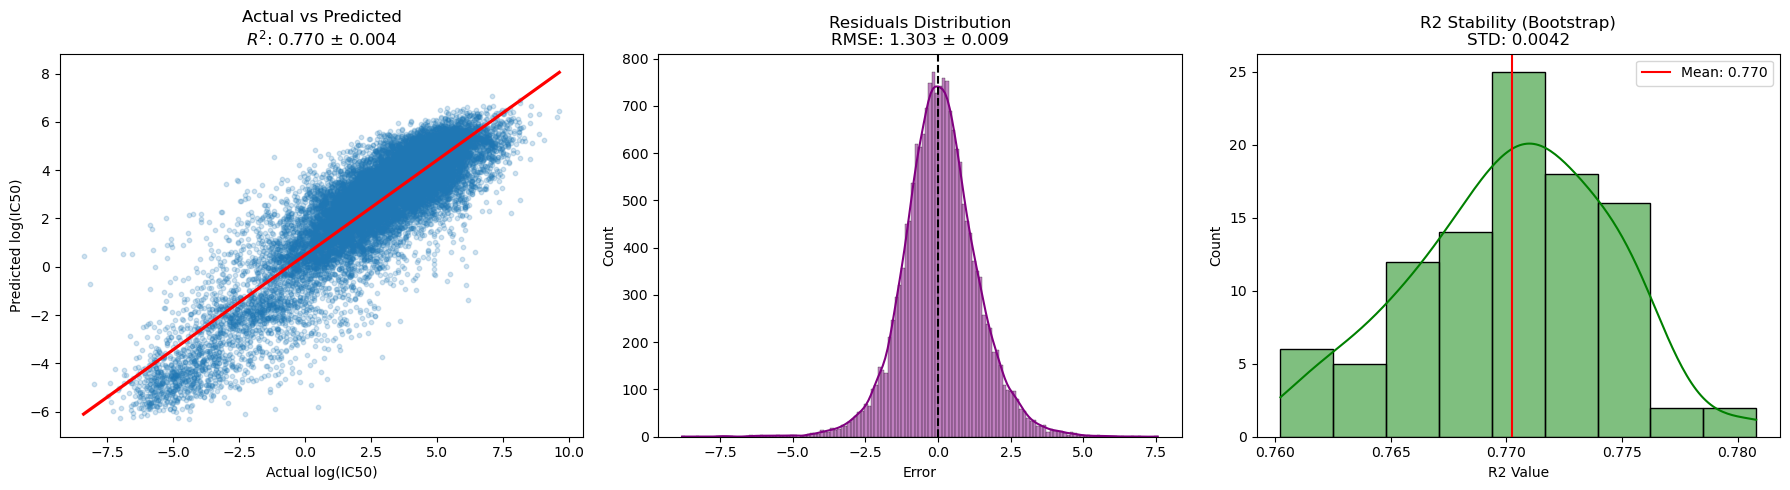

In [11]:
y_pred = final_model.predict(X_test)

# 2. Hàm tính toán Bootstrapping để lấy Mean và STD
def get_bootstrap_metrics(y_true, y_pred, n_iterations=100):
    metrics = {
        'r2': [],
        'pearson': [],
        'spearman': [],
        'rmse': []
    }
    
    print(f"Đang chạy Bootstrapping ({n_iterations} lần)...")
    for i in range(n_iterations):
        # Lấy mẫu lại (có lặp lại) từ tập dự đoán
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=i)
        
        metrics['r2'].append(r2_score(y_true_sample, y_pred_sample))
        metrics['pearson'].append(pearsonr(y_true_sample, y_pred_sample)[0])
        metrics['spearman'].append(spearmanr(y_true_sample, y_pred_sample)[0])
        metrics['rmse'].append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        
    return metrics

# Chạy bootstrapping
bootstrapped_results = get_bootstrap_metrics(y_test, y_pred, n_iterations=100)

# Tính Mean và STD
r2_mean, r2_std = np.mean(bootstrapped_results['r2']), np.std(bootstrapped_results['r2'])
p_mean, p_std = np.mean(bootstrapped_results['pearson']), np.std(bootstrapped_results['pearson'])
s_mean, s_std = np.mean(bootstrapped_results['spearman']), np.std(bootstrapped_results['spearman'])
rmse_mean, rmse_std = np.mean(bootstrapped_results['rmse']), np.std(bootstrapped_results['rmse'])

# 3. In kết quả
print("\n" + "="*40)
print(f"{'Metric':<12} | {'Mean':<10} | {'STD':<10}")
print("-" * 40)
print(f"{'R2':<12} | {r2_mean:<10.4f} | {r2_std:<10.4f}")
print(f"{'Pearson':<12} | {p_mean:<10.4f} | {p_std:<10.4f}")
print(f"{'Spearman':<12} | {s_mean:<10.4f} | {s_std:<10.4f}")
print(f"{'RMSE':<12} | {rmse_mean:<10.4f} | {rmse_std:<10.4f}")
print("="*40)

# 4. Vẽ biểu đồ
plt.figure(figsize=(18, 5))

# Biểu đồ 1: Actual vs Predicted
plt.subplot(1, 3, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
plt.title(f'Actual vs Predicted\n$R^2$: {r2_mean:.3f} ± {r2_std:.3f}')
plt.xlabel('Actual log(IC50)')
plt.ylabel('Predicted log(IC50)')

# Biểu đồ 2: Phân phối lỗi (Residuals)
plt.subplot(1, 3, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(x=0, color='black', linestyle='--')
plt.title(f'Residuals Distribution\nRMSE: {rmse_mean:.3f} ± {rmse_std:.3f}')
plt.xlabel('Error')

# Biểu đồ 3: Phân phối R2 từ Bootstrapping
plt.subplot(1, 3, 3)
sns.histplot(bootstrapped_results['r2'], kde=True, color='green')
plt.axvline(x=r2_mean, color='red', linestyle='-', label=f'Mean: {r2_mean:.3f}')
plt.title(f'R2 Stability (Bootstrap)\nSTD: {r2_std:.4f}')
plt.xlabel('R2 Value')
plt.legend()

plt.tight_layout()
plt.show()

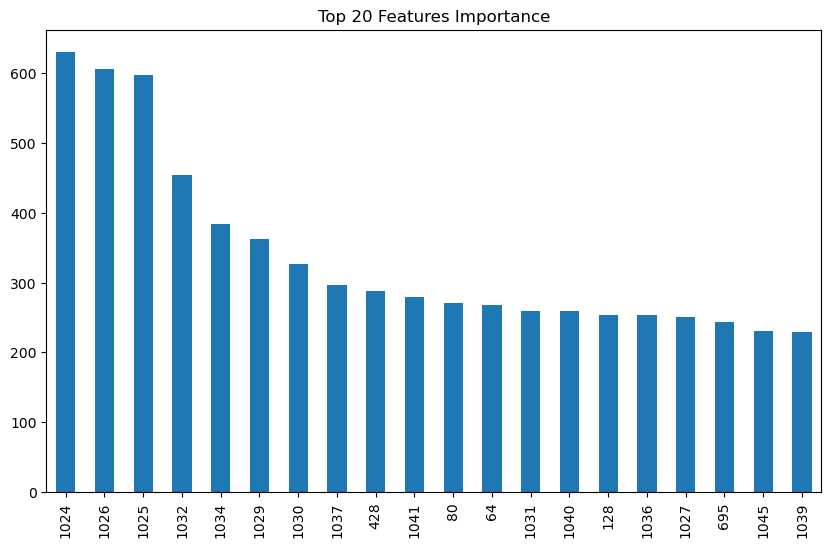

In [12]:
import matplotlib.pyplot as plt

# Lấy 20 đặc trưng quan trọng nhất
feat_imp = pd.Series(final_model.feature_importances_).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(20).plot(kind='bar')
plt.title("Top 20 Features Importance")
plt.show()

In [13]:
import joblib
import os

# Tạo thư mục models nếu chưa có
os.makedirs('../models', exist_ok=True)

# Lưu mô hình
model_path = '../models/lgbm_cold_split.pkl'
joblib.dump(final_model, model_path)
print(f"Đã lưu mô hình tại: {model_path}")

Đã lưu mô hình tại: ../models/lgbm_cold_split.pkl
